In [1]:
#Ejercicio 1

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

X, y = make_regression(n_samples=200, n_features=3, noise=15, random_state=42)

# 1. Separar X e y con test y train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. Imprimir la forma (shape) de X_train y X_test
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

# 3. Por qué usar random_state=42 en train_test_split?
#El parámetro `random_state=42` se utiliza para garantizar la reproducibilidad de los resultados

Shape of X_train: (150, 3)
Shape of X_test: (50, 3)


In [2]:
#Ejercicio 2

from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# 1. Crear Random Forest
rf_model = RandomForestRegressor(n_estimators=50, random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento
rf_model.fit(X_train, y_train)

# 3. Hacer predicciones con los datos de prueba
y_pred = rf_model.predict(X_test)

# 4. Calcular el RMSE y el R2 score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 31.060077682474056
R2 Score: 0.9016306566641975


In [3]:
#Ejercicio 3

real = [700, 850, 600, 900]
predicho = [720, 800, 650, 880]

# 1. Calcula el error de predicción (predicho - real)
error = [p - r for p, r in zip(predicho, real)]
print("Errores de predicción:", error)

# 2.Elevar el error al cuadrado y calcular el promedio
error_cuadrado = [e**2 for e in error]
promedio_error_cuadrado = sum(error_cuadrado) / len(error_cuadrado)
print("Promedio del error al cuadrado:", promedio_error_cuadrado)

# 3. Calcular la raíz cuadrada del promedio del error al cuadrado (RMSE)
rmse_manual = np.sqrt(promedio_error_cuadrado)
print("RMSE (manual):", rmse_manual)

# 4.¿Cuanto es el error medio del modelo, en euros?

Errores de predicción: [20, -50, 50, -20]
Promedio del error al cuadrado: 1450.0
RMSE (manual): 38.07886552931954


In [7]:
#Ejercicio 4

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

iris = load_iris()
X, y = iris.data, iris.target

# 1. Separar X e y con test y train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Entrenar un modelo Random Forest con los datos de entrenamiento
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# 3. Generar predicciones con los datos de prueba
y_pred = rf_classifier.predict(X_test)

# 4. Calcular el accuracy del modelo
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy del modelo:", accuracy)

Accuracy del modelo: 0.9


In [5]:
#Ejercicio 5

#Un modelo que detecta spam en correos electrónicos tiene los siguientes resultados:
#Verdaderos Positivos (TP): 35 (spam detectado correctamente)
#Verdaderos Negativos (TN): 50 (correo normal identificado bien)
#Falsos Positivos (FP): 5 (correo normal marcado como spam)
#Falsos Negativos (FN): 10 (spam que no se detectó)

# 1. Calcular la accuracy del modelo
TP = 35
TN = 50
FP = 5
FN = 10

accuracy = (TP + TN) / (TP + TN + FP + FN)
print("Accuracy del modelo:", accuracy)

# 2. Calcular la precisión del modelo
precision = TP / (TP + FP)
print("Precisión del modelo:", precision)

# 3. Calcular el recall del modelo
recall = TP / (TP + FN)
print("Recall del modelo:", recall)

# 4. ¿Qué métrica te preocuparía más si este fuera un filtro para detectar una enfermedad grave en vez de spam?
# En el caso de una enfermedad grave, te preocuparía más el recall (sensibilidad), ya que quieres minimizar los falsos negativos (pacientes con la enfermedad que no son detectados).

Accuracy del modelo: 0.85
Precisión del modelo: 0.875
Recall del modelo: 0.7777777777777778


In [1]:
#Ejercicio 6
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y_real = make_blobs(n_samples=150, centers=3, cluster_std=1.0, random_state=42)

# 1. Crear un modelo KMeans con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. Ajustar el modelo a los datos y obtener las etiquetas de los clusters
kmeans.fit(X)
y_pred = kmeans.predict(X)

# 3. Consulta las coordenadas de los centroides de los clusters
centroides = kmeans.cluster_centers_
print("Coordenadas de los centroides de los clusters:", centroides)

# 4. ¿Crees que K-Means ha encontrado 3 grupos razonablemente separados?

Coordenadas de los centroides de los clusters: [[-2.70146566  8.90287872]
 [-6.75399588 -6.88944874]
 [ 4.58407676  2.1431444 ]]


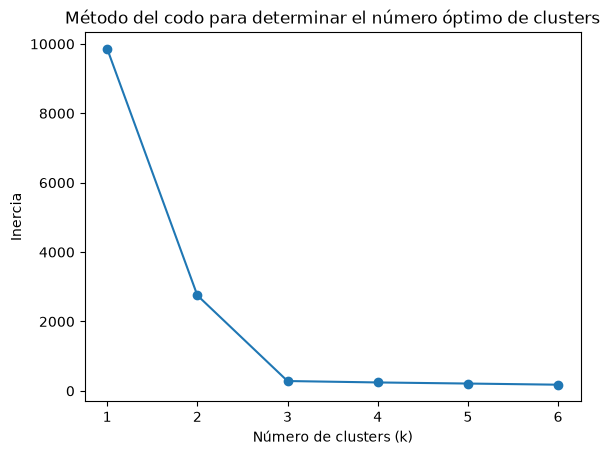

In [2]:
#Ejercicio 7
#Usa los mismos datos del ejercicio anterior

# 1. Calcula la inercia del modelo KMeans entre 1 y 6
inercias = []
for n in range(1, 7):
    kmeans = KMeans(n_clusters=n, random_state=42, n_init=10)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)

# 2. Dibuja un gráfico de lineas con k en el eje x y la inercia en el eje y
import matplotlib.pyplot as plt

plt.plot(range(1, 7), inercias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo para determinar el número óptimo de clusters')
plt.show()

# 3. Mirando la gráfica, identifica en qué valor de k está el "codo" (donde la mejora empieza a ser pequeña).

In [3]:
#Ejercicio 8
#Sigue usando los datos del ejercicio 6

# 1. Calcula el coeficiente de silueta para k=2, k=3 y k=4
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    y_pred = kmeans.predict(X)
    score = silhouette_score(X, y_pred)
    silhouette_scores.append(score)

print("Coeficientes de silueta para k=2, k=3 y k=4:", silhouette_scores)

# 2. ¿Cuál tiene k tiene mejor separación?

# 3. ¿Coincide el k con mejor silueta con el codo que identificaste en el ejercicio anterior?

Coeficientes de silueta para k=2, k=3 y k=4: [0.704166429664473, 0.844795031920084, 0.6898813710185757]


In [6]:
#Ejercicio 9
#Usa el clasificador y los datos de train el ejercicio 4

from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Calcula cross_val_score con cv=5 y scoring= "f1_macro" 
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris,y_iris,test_size=0.2,random_state=42,stratify=y_iris)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(rf_classifier, X_train_iris, y_train_iris, cv=5, scoring="f1_macro")
print("Puntuaciones de validación cruzada:", scores)   

# 2. Imprime las 5 puntuaciones medias, una por cada particion
print("Puntuación media de validación cruzada:", scores.mean())

# 3. Calcula la media y la desviación estándar de las puntuaciones
mean_score = scores.mean()
std_score = scores.std()
print("Media de validación cruzada:", mean_score)
print("Desviación estándar de validación cruzada:", std_score)


# 4. Compara la media obtenida aquí con el accuracy del split de train y test del ejercicio 4. ¿Es fiable la media de validación cruzada para estimar el rendimiento del modelo en datos no vistos?
# La media de validación cruzada proporciona una estimación más robusta del rendimiento del modelo


Puntuaciones de validación cruzada: [0.91534392 0.95816993 0.95816993 0.95816993 0.95816993]
Puntuación media de validación cruzada: 0.9496047307812014
Media de validación cruzada: 0.9496047307812014
Desviación estándar de validación cruzada: 0.017130407718643024


In [9]:
#Ejercicio 10
#Usa el clasificador y los datos de train el ejercicio 4

from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 3, 5],}

# 1. Crea un GridSearchCV con el param_grid dado, cv=5 y scoring="f1_macro" 
grid_search = GridSearchCV(rf_classifier, param_grid, cv=5, scoring="f1_macro")

# 2. Ajusta el GridSearchCV a los datos de entrenamiento
grid_search.fit(X_train_iris, y_train_iris)

# 3. Consulta la mejor combinación de hiperparámetros
best_params = grid_search.best_params_
print("Mejores hiperparámetros:", best_params)
print("Mejor F1 medio en CV:", grid_search.best_score_)

# 4. ¿Cuántas combinaciones distintas ha tenido que probar el GridSearch en total?
total_combinations = grid_search.n_splits_ * len(param_grid['n_estimators']) * len(param_grid['max_depth'])
print("Número total de combinaciones probadas:", total_combinations)

Mejores hiperparámetros: {'max_depth': 3, 'n_estimators': 50}
Mejor F1 medio en CV: 0.9581699346405228
Número total de combinaciones probadas: 30
